Epoch 0, Loss: 18256700.0
Epoch 500, Loss: 782.3910522460938
Epoch 1000, Loss: 163.5027618408203
Epoch 1500, Loss: 63.04288864135742
Epoch 2000, Loss: 50.3707389831543
Epoch 2500, Loss: 176762.15625
Epoch 3000, Loss: 548.3980712890625
Epoch 3500, Loss: 32.386165618896484
Epoch 4000, Loss: 28.24355125427246
Epoch 4500, Loss: 36.39799499511719


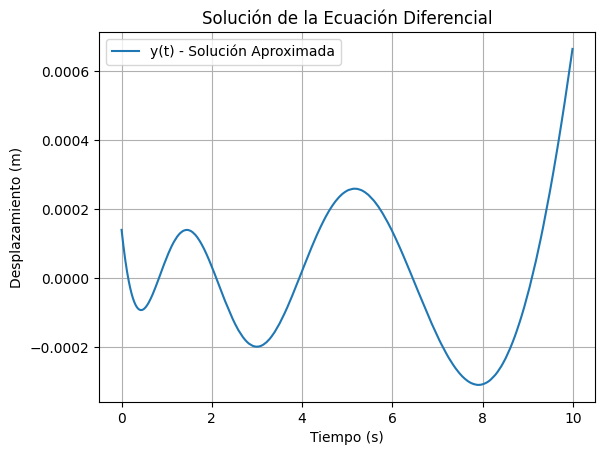

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del sistema
m = 1.0          # Masa en kg
k = 25000.0      # Constante del resorte
lmbda = 750.0    # Coeficiente de amortiguamiento
F_peak = 0.1     # Pico del perfil del terreno
T = 10         # Tiempo total de simulación
time_step = 0.01 # Paso de tiempo

# Perfil del terreno constante
def terrain_profile(t):
    return tf.constant(F_peak, dtype=tf.float32)  # Fuerza constante

# Generar tiempos y valores de fuerza
t_train = tf.range(0, T, time_step, dtype=tf.float32)
F_train = terrain_profile(t_train)

# Red neuronal para aproximar y(t)
class DifferentialSolverNN(tf.keras.Model):
    def __init__(self):
        super(DifferentialSolverNN, self).__init__()
        self.hidden1 = tf.keras.layers.Dense(50, activation='tanh')
        self.hidden2 = tf.keras.layers.Dense(50, activation='tanh')
        self.output_layer = tf.keras.layers.Dense(1)  # Salida única: y(t)

    def call(self, t):
        x = tf.expand_dims(t, axis=1)  # Convertir tiempo en una entrada compatible
        x = self.hidden1(x)
        x = self.hidden2(x)
        return self.output_layer(x)


def residual(model, t, F_t):
    with tf.GradientTape(persistent=True) as tape1:
        tape1.watch(t)  # Registrar t para calcular derivadas
        y = model(t)    # Aproximación de y(t)
        dy_dt = tape1.gradient(y, t)   # Primera derivada: y'(t)
    d2y_dt2 = tape1.gradient(dy_dt, t)  # Segunda derivada: y''(t)
    del tape1  

    # Residuo de la ecuación diferencial
    res = m * d2y_dt2 + lmbda * dy_dt + k * y - F_t
    return res


def loss_fn(model, t, F_t):
    res = residual(model, t, F_t)
    loss = tf.reduce_mean(tf.square(res))  
    return loss


def train(model, t_train, F_train, epochs=5000, lr=0.001):
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            loss = loss_fn(model, t_train, F_train)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch}, Loss: {loss.numpy()}")


def plot_solution(model, t_train):
    y_vals = model(t_train).numpy()
    
    plt.plot(t_train, y_vals, label="y(t) - Solución Aproximada")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Desplazamiento (m)")
    plt.title("Solución de la Ecuación Diferencial")
    plt.legend()
    plt.grid()
    plt.show()


model = DifferentialSolverNN()
train(model, t_train, F_train)


plot_solution(model, t_train)



In [60]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Funciones para c(t) y c'(t) por tramos
def c_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5 * (t - 1)
    elif 1.2 <= t < 1.4:
        return 0.1
    elif 1.4 <= t < 1.6:
        return -0.5 * (t - 1.6)
    else:
        return 0

def c_prime_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5
    elif 1.2 <= t < 1.4:
        return 0
    elif 1.4 <= t < 1.6:
        return -0.5
    else:
        return 0

# Parámetros iniciales del sistema
padron = 107647
m = padron / 200  # masa [kg]
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Inicializar listas para las señales y salidas
X = []
y = []

# Rango de valores de k y L para generar las señales
k_values = np.linspace(10000, 30000, 10)  # Rango de valores de k [N/m]
L_values = np.linspace(100, 10000, 10)  # Rango de valores de L [Ns/m]

# Generación de datos de entrenamiento
for k in k_values:
    for L in L_values:
        t_steps = int(t_end / h)  # número de pasos
        t_array = np.arange(t_steps) * h  # array de tiempo
        u = np.zeros(t_steps)
        v = np.zeros(t_steps)
        u[0] = u_n
        v[0] = v_n

        for n in range(t_steps - 1):
            t_n = t_array[n]
            t_n1 = t_array[n] + h
            
            # Valores de c(t) y c'(t) en t_n y t_n+1
            c_n = c_t(t_n)
            c_n1 = c_t(t_n1)
            c_pn = c_prime_t(t_n)
            c_pn1 = c_prime_t(t_n1)

            # Denominador común para u[n+1] y v[n+1]
            denom = (beta**2) * (h**2) * k + beta * L * h + m

            # Actualización de u[n+1]
            u[n + 1] = (
                - (beta**2) * L * c_pn * h**2
                + (beta**2) * L * c_pn1 * h**2
                - (beta**2) * c_n * h**2 * k
                + (beta**2) * c_n1 * h**2 * k
                + (beta**2) * h**2 * k * u[n]
                + beta * L * c_pn * h**2
                + beta * L * h * u[n]
                + beta * c_n * h**2 * k
                - beta * h**2 * k * u[n]
                + h * m * v[n]
                + m * u[n]
            ) / denom

            # Actualización de v[n+1]
            v[n + 1] = (
                (beta**2) * h**2 * k * v[n]
                - beta * L * c_pn * h
                + beta * L * c_pn1 * h
                + beta * L * h * v[n]
                - beta * c_n * h * k
                + beta * c_n1 * h * k
                - beta * h**2 * k * v[n]
                + L * c_pn * h
                - L * h * v[n]
                + c_n * h * k
                - h * k * u[n]
                + m * v[n]
            ) / denom

        # Añadir la señal u(t) como entrada y las constantes k y L como salida
        X.append(u)
        y.append([k, L])

# Convertir listas en arrays de numpy
X = np.array(X)
y = np.array(y)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Definir la red neuronal con TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Dos salidas: K y L
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=1000, batch_size=50, validation_data=(X_test, y_test))

# Evaluar el modelo
loss = model.evaluate(X_test, y_test)
print(f"Loss: {loss}")

# Usar el modelo para hacer predicciones
predicciones = model.predict(X_test)
print(f"Predicciones para las primeras muestras de prueba: \n{predicciones}")


Epoch 1/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 236719472.0000 - val_loss: 232307280.0000
Epoch 2/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 240912448.0000 - val_loss: 232297952.0000
Epoch 3/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 243385328.0000 - val_loss: 232287136.0000
Epoch 4/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 233710944.0000 - val_loss: 232274640.0000
Epoch 5/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 241207536.0000 - val_loss: 232260816.0000
Epoch 6/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 247650768.0000 - val_loss: 232245248.0000
Epoch 7/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 240029632.0000 - val_loss: 232227808.0000
Epoch 8/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 241597904.0000 - val_loss: 232208256.0000
Epoch 9/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 241332400.0000 - val_loss: 232186576.0000
Epoch 10/1000
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 239249680.0000 - val_loss: 2321

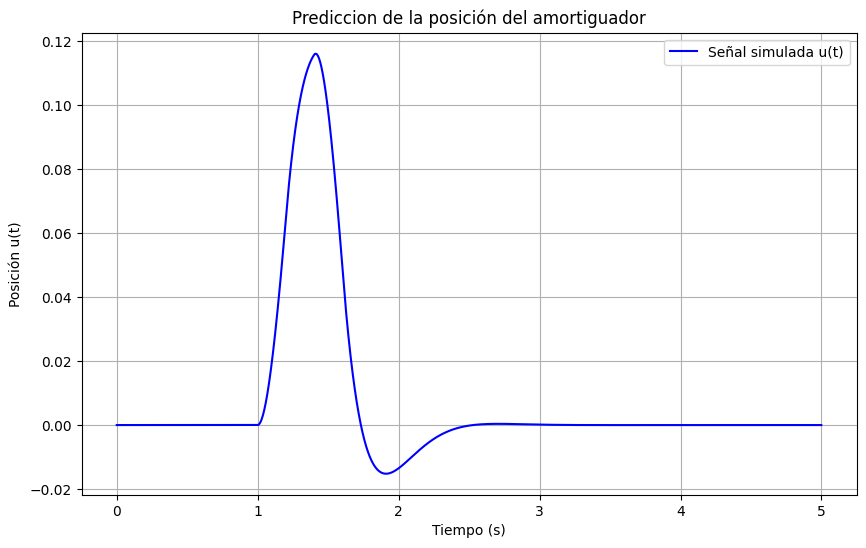

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Constantes predichas por la red neuronal:
Predicción de k: 20976.92578125
Predicción de L: 5111.6796875
Constantes reales:
Real k: 20000
Real L: 5000


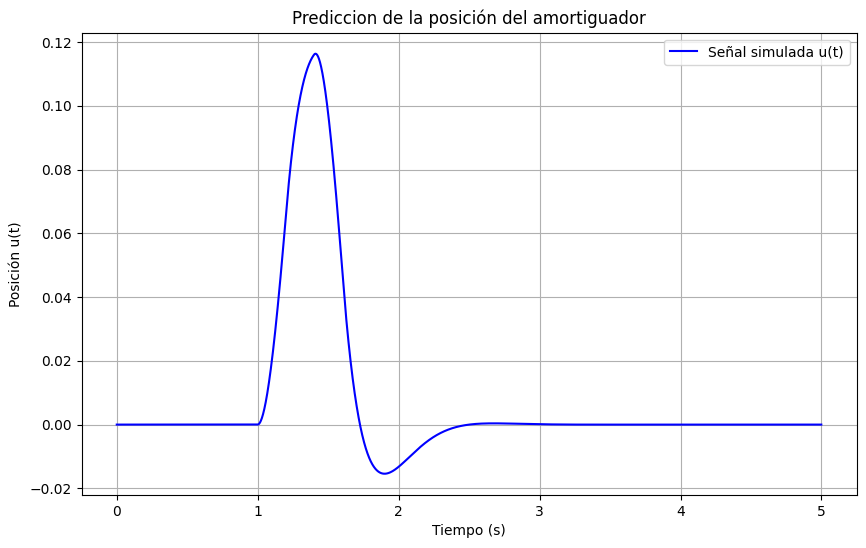

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Funciones para c(t) y c'(t) por tramos
def c_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5 * (t - 1)
    elif 1.2 <= t < 1.4:
        return 0.1
    elif 1.4 <= t < 1.6:
        return -0.5 * (t - 1.6)
    else:
        return 0

def c_prime_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5
    elif 1.2 <= t < 1.4:
        return 0
    elif 1.4 <= t < 1.6:
        return -0.5
    else:
        return 0

# Parámetros de la simulación
m = 107647 / 200  # masa [kg]
k_real = 20000  # constante elástica [N/m]
L_real = 5000  # constante de amortiguación [Ns/m]
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Generar la señal u(t) con k_real y L_real
t_steps = int(t_end / h)  # número de pasos
t_array = np.arange(t_steps) * h  # array de tiempo
u = np.zeros(t_steps)
v = np.zeros(t_steps)
u[0] = u_n
v[0] = v_n

# Simulación para obtener la señal u(t)
for n in range(t_steps - 1):
    t_n = t_array[n]
    t_n1 = t_array[n] + h
    
    # Valores de c(t) y c'(t) en t_n y t_n+1
    c_n = c_t(t_n)
    c_n1 = c_t(t_n1)
    c_pn = c_prime_t(t_n)
    c_pn1 = c_prime_t(t_n1)

    # Denominador común para u[n+1] y v[n+1]
    denom = (beta**2) * (h**2) * k_real + beta * L_real * h + m

    # Actualización de u[n+1]
    u[n + 1] = (
        - (beta**2) * L_real * c_pn * h**2
        + (beta**2) * L_real * c_pn1 * h**2
        - (beta**2) * c_n * h**2 * k_real
        + (beta**2) * c_n1 * h**2 * k_real
        + (beta**2) * h**2 * k_real * u[n]
        + beta * L_real * c_pn * h**2
        + beta * L_real * h * u[n]
        + beta * c_n * h**2 * k_real
        - beta * h**2 * k_real * u[n]
        + h * m * v[n]
        + m * u[n]
    ) / denom

    # Actualización de v[n+1]
    v[n + 1] = (
        (beta**2) * h**2 * k_real * v[n]
        - beta * L_real * c_pn * h
        + beta * L_real * c_pn1 * h
        + beta * L_real * h * v[n]
        - beta * c_n * h * k_real
        + beta * c_n1 * h * k_real
        - beta * h**2 * k_real * v[n]
        + L_real * c_pn * h
        - L_real * h * v[n]
        + c_n * h * k_real
        - h * k_real * u[n]
        + m * v[n]
    ) / denom
# Graficar la señal generada
plt.figure(figsize=(10, 6))
plt.plot(t_array, u, label="Señal simulada u(t)", color="blue")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.title("Prediccion de la posición del amortiguador")
plt.grid(True)
plt.legend()
plt.show()

# Convertir la señal u(t) a un formato adecuado para la red
X_new = u.reshape(1, -1)  # Convertir la señal u(t) en un vector de entrada

# Evaluar el modelo previamente entrenado (usando el modelo ya entrenado en el código anterior)
predicciones = model.predict(X_new)



# Mostrar las predicciones de la red
k_pred, L_pred = predicciones[0]
print(f"Constantes predichas por la red neuronal:")
print(f"Predicción de k: {k_pred}")
print(f"Predicción de L: {L_pred}")
print(f"Constantes reales:")
print(f"Real k: {k_real}")
print(f"Real L: {L_real}")


# Parámetros de la simulación
m = 107647 / 200  # masa [kg]
k_real = k_pred  # constante elástica [N/m]
L_real = L_pred  # constante de amortiguación [Ns/m]
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Generar la señal u(t) con k_real y L_real
t_steps = int(t_end / h)  # número de pasos
t_array = np.arange(t_steps) * h  # array de tiempo
u = np.zeros(t_steps)
v = np.zeros(t_steps)
u[0] = u_n
v[0] = v_n

# Simulación para obtener la señal u(t)
for n in range(t_steps - 1):
    t_n = t_array[n]
    t_n1 = t_array[n] + h
    
    # Valores de c(t) y c'(t) en t_n y t_n+1
    c_n = c_t(t_n)
    c_n1 = c_t(t_n1)
    c_pn = c_prime_t(t_n)
    c_pn1 = c_prime_t(t_n1)

    # Denominador común para u[n+1] y v[n+1]
    denom = (beta**2) * (h**2) * k_real + beta * L_real * h + m

    # Actualización de u[n+1]
    u[n + 1] = (
        - (beta**2) * L_real * c_pn * h**2
        + (beta**2) * L_real * c_pn1 * h**2
        - (beta**2) * c_n * h**2 * k_real
        + (beta**2) * c_n1 * h**2 * k_real
        + (beta**2) * h**2 * k_real * u[n]
        + beta * L_real * c_pn * h**2
        + beta * L_real * h * u[n]
        + beta * c_n * h**2 * k_real
        - beta * h**2 * k_real * u[n]
        + h * m * v[n]
        + m * u[n]
    ) / denom

    # Actualización de v[n+1]
    v[n + 1] = (
        (beta**2) * h**2 * k_real * v[n]
        - beta * L_real * c_pn * h
        + beta * L_real * c_pn1 * h
        + beta * L_real * h * v[n]
        - beta * c_n * h * k_real
        + beta * c_n1 * h * k_real
        - beta * h**2 * k_real * v[n]
        + L_real * c_pn * h
        - L_real * h * v[n]
        + c_n * h * k_real
        - h * k_real * u[n]
        + m * v[n]
    ) / denom


# Graficar la señal generada
plt.figure(figsize=(10, 6))
plt.plot(t_array, u, label="Señal simulada u(t)", color="blue")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.title("Prediccion de la posición del amortiguador")
plt.grid(True)
plt.legend()
plt.show()


In [84]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Parámetros iniciales del sistema
padron = 107647
m = padron / 200  # masa [kg]
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo
c = 0.1  # excitación uniforme [m]
c_prime = 0

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Inicializar listas para las señales y salidas
X = []
y = []

# Rango de valores de k y L para generar las señales
k_values = np.linspace(10000, 30000, 10)  # Rango de valores de k [N/m]
L_values = np.linspace(0, 100, 10)  # Rango de valores de L [Ns/m]

# Generación de datos de entrenamiento
for k in k_values:
    for L in L_values:
        t_steps = int(t_end / h)  # número de pasos
        t_array = np.arange(t_steps) * h  # array de tiempo
        u = np.zeros(t_steps)
        v = np.zeros(t_steps)
        u[0] = u_n
        v[0] = v_n

        for n in range(t_steps - 1):
            u[n+1] = ((beta**2) * (h**2) * k * u[n] + beta * L * c_prime * (h**2) + beta * L * h * u[n] +
                      beta * c * (h**2) * k - beta * (h**2) * k * u[n] + h * m * v[n] + m * u[n]) / \
                     ((beta**2) * (h**2) * k + beta * L * h + m)
            v[n+1] = ((beta**2) * (h**2) * k * v[n] + beta * L * h * v[n] - beta * (h**2) * k * v[n] +
                      L * c_prime * h - L * h * v[n] + c * h * k - h * k * u[n] + m * v[n]) / \
                     ((beta**2) * (h**2) * k + beta * L * h + m)

        # Añadir la señal u(t) como entrada y las constantes k y L como salida
        X.append(u)
        y.append([k, L])

# Convertir listas en arrays de numpy
X = np.array(X)
y = np.array(y)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Definir la red neuronal con TensorFlow
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Dos salidas: K y L
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse')

# Entrenar el modelo
model.fit(X_train, y_train, epochs=700, batch_size=64, validation_data=(X_test, y_test))

# Evaluar el modelo
loss = model.evaluate(X_test, y_test)
print(f"Loss: {loss}")

# Usar el modelo para hacer predicciones
predicciones = model.predict(X_test)
print(f"Predicciones para las primeras muestras de prueba: \n{predicciones}")

Epoch 1/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 474ms/step - loss: 215418784.0000 - val_loss: 231173712.0000
Epoch 2/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 210650992.0000 - val_loss: 231100064.0000
Epoch 3/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 219117504.0000 - val_loss: 231019264.0000
Epoch 4/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 221017600.0000 - val_loss: 230929232.0000
Epoch 5/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 219591344.0000 - val_loss: 230829744.0000
Epoch 6/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 215972352.0000 - val_loss: 230720208.0000
Epoch 7/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 219718960.0000 - val_loss: 230600032.0000
Epoch 8/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 215619008.0000 - val_loss: 230468784.0000
Epoch 9/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 215978272.0000 - val_loss: 230325376.0000
Epoch 10/700
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 213091216.0000 - val_loss: 230168832.000

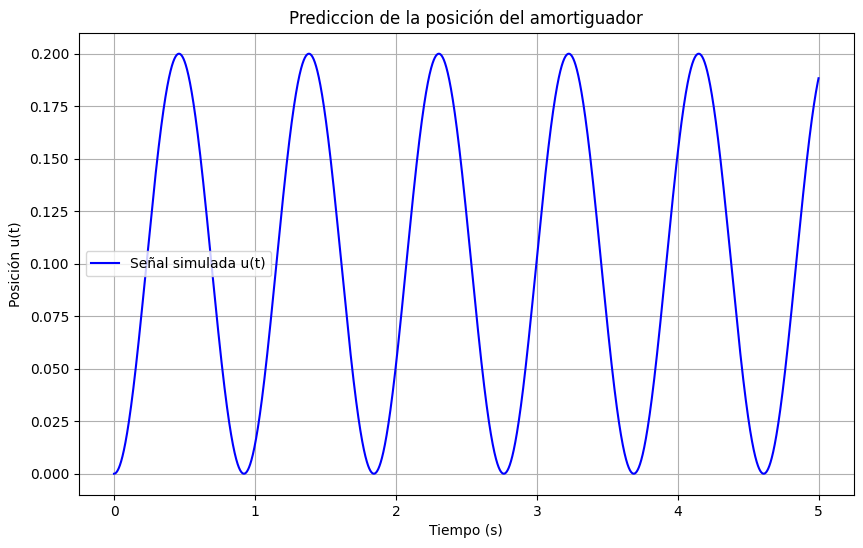

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Constantes predichas por la red neuronal:
Predicción de k: 25649.525390625
Predicción de L: 55.71197509765625
Constantes reales:
Real k: 25000
Real L: 0


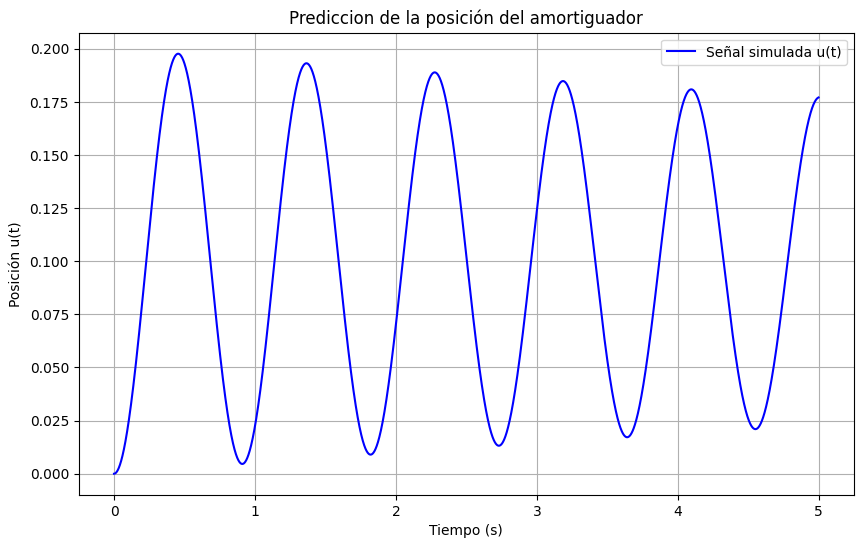

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf



# Parámetros de la simulación
m = 107647 / 200  # masa [kg]
k_real = 25000  # constante elástica [N/m]
L_real = 0  # constante de amortiguación [Ns/m]
k= k_real
L = L_real
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo
c = 0.1  # excitación uniforme [m]
c_prime = 0

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Generar la señal u(t) con k_real y L_real
t_steps = int(t_end / h)  # número de pasos
t_array = np.arange(t_steps) * h  # array de tiempo
u = np.zeros(t_steps)
v = np.zeros(t_steps)
u[0] = u_n
v[0] = v_n

# Simulación para obtener la señal u(t)
for n in range(t_steps - 1):
    u[n+1] = ((beta**2) * (h**2) * k * u[n] + beta * L * c_prime * (h**2) + beta * L * h * u[n] + beta * c * (h**2) * k - beta * (h**2) * k * u[n] + h * m * v[n] + m * u[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)
    v[n+1] = ((beta**2) * (h**2) * k * v[n] + beta * L * h * v[n] - beta * (h**2) * k * v[n] + L * c_prime * h - L * h * v[n] + c * h * k - h * k * u[n] + m * v[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)

    
# Graficar la señal generada
plt.figure(figsize=(10, 6))
plt.plot(t_array, u, label="Señal simulada u(t)", color="blue")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.title("Prediccion de la posición del amortiguador")
plt.grid(True)
plt.legend()
plt.show()

# Convertir la señal u(t) a un formato adecuado para la red
X_new = u.reshape(1, -1)  # Convertir la señal u(t) en un vector de entrada

# Evaluar el modelo previamente entrenado (usando el modelo ya entrenado en el código anterior)
predicciones = model.predict(X_new)



# Mostrar las predicciones de la red
k_pred, L_pred = predicciones[0]
print(f"Constantes predichas por la red neuronal:")
print(f"Predicción de k: {k_pred}")
print(f"Predicción de L: {L_pred}")
print(f"Constantes reales:")
print(f"Real k: {k_real}")
print(f"Real L: {L_real}")


# Parámetros de la simulación
m = 107647 / 200  # masa [kg]
k_real = k_pred  # constante elástica [N/m]
L_real = L_pred  # constante de amortiguación [Ns/m]
k= k_real
L = L_real
t_end = 5  # tiempo final [s]
h = 0.001  # paso de tiempo
beta = 0.5  # valor de beta fijo

# Condiciones iniciales
u_n = 0.0  # Posición inicial
v_n = 0.0  # Velocidad inicial

# Generar la señal u(t) con k_real y L_real
t_steps = int(t_end / h)  # número de pasos
t_array = np.arange(t_steps) * h  # array de tiempo
u = np.zeros(t_steps)
v = np.zeros(t_steps)
u[0] = u_n
v[0] = v_n

# Simulación para obtener la señal u(t)
for n in range(t_steps - 1):
    u[n+1] = ((beta**2) * (h**2) * k * u[n] + beta * L * c_prime * (h**2) + beta * L * h * u[n] + beta * c * (h**2) * k - beta * (h**2) * k * u[n] + h * m * v[n] + m * u[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)
    v[n+1] = ((beta**2) * (h**2) * k * v[n] + beta * L * h * v[n] - beta * (h**2) * k * v[n] + L * c_prime * h - L * h * v[n] + c * h * k - h * k * u[n] + m * v[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)
# 


# Graficar la señal generada
plt.figure(figsize=(10, 6))
plt.plot(t_array, u, label="Señal simulada u(t)", color="blue")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.title("Prediccion de la posición del amortiguador")
plt.grid(True)
plt.legend()
plt.show()

In [88]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# Funciones para c(t) y c'(t) por tramos (mismo código que proporcionaste)
def c_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5 * (t - 1)
    elif 1.2 <= t < 1.4:
        return 0.1
    elif 1.4 <= t < 1.6:
        return -0.5 * (t - 1.6)
    else:
        return 0

def c_prime_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5
    elif 1.2 <= t < 1.4:
        return 0
    elif 1.4 <= t < 1.6:
        return -0.5
    else:
        return 0

# Método para simular la señal u(t) basado en las constantes k y L
def simulate_amortiguador(k, L, m=107647/200, t_end=5, h=0.001, beta=0.5):
    """
    Simula el comportamiento del amortiguador con los valores dados de k y L.
    
    k: constante elástica (N/m)
    L: constante de amortiguación (Ns/m)
    m: masa del sistema (kg)
    t_end: tiempo final de simulación (s)
    h: paso de tiempo (s)
    beta: parámetro de amortiguación
    """
    t_steps = int(t_end / h)  # número de pasos
    t_array = np.arange(t_steps) * h  # array de tiempo
    u = np.zeros(t_steps)
    v = np.zeros(t_steps)
    u_n = 0.0  # Posición inicial
    v_n = 0.0  # Velocidad inicial
    u[0] = u_n
    v[0] = v_n

    # Simulación de la dinámica del amortiguador
    for n in range(t_steps - 1):
        t_n = t_array[n]
        t_n1 = t_array[n] + h

        # Valores de c(t) y c'(t) en t_n y t_n+1
        c_n = c_t(t_n)
        c_n1 = c_t(t_n1)
        c_pn = c_prime_t(t_n)
        c_pn1 = c_prime_t(t_n1)

        # Denominador común para u[n+1] y v[n+1]
        denom = (beta**2) * (h**2) * k + beta * L * h + m

        # Actualización de u[n+1]
        u[n + 1] = (
            - (beta**2) * L * c_pn * h**2
            + (beta**2) * L * c_pn1 * h**2
            - (beta**2) * c_n * h**2 * k
            + (beta**2) * c_n1 * h**2 * k
            + (beta**2) * h**2 * k * u[n]
            + beta * L * c_pn * h**2
            + beta * L * h * u[n]
            + beta * c_n * h**2 * k
            - beta * h**2 * k * u[n]
            + h * m * v[n]
            + m * u[n]
        ) / denom

        # Actualización de v[n+1]
        v[n + 1] = (
            (beta**2) * h**2 * k * v[n]
            - beta * L * c_pn * h
            + beta * L * c_pn1 * h
            + beta * L * h * v[n]
            - beta * c_n * h * k
            + beta * c_n1 * h * k
            - beta * h**2 * k * v[n]
            + L * c_pn * h
            - L * h * v[n]
            + c_n * h * k
            - h * k * u[n]
            + m * v[n]
        ) / denom

    return u  # Regresar la señal u(t)

# Función para generar datos de entrenamiento y prueba
def generate_data(num_samples=1000):
    X = []
    y = []
    for _ in range(num_samples):
        # Generar constantes k y L aleatorias
        k = np.random.uniform(10000, 30000)  # Rango de k
        L = np.random.uniform(5000, 10000)   # Rango de L

        # Obtener la señal u(t) para cada par de constantes
        u = simulate_amortiguador(k, L)
        
        # Añadir la señal y las constantes como salida
        X.append(u)
        y.append([k, L])
    
    return np.array(X), np.array(y)

# Generar datos de entrenamiento
X, y = generate_data(num_samples=1000)

# Estandarización de las señales (es importante para las redes neuronales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, input_shape=(5000,), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Salida: k y L
])

# Compilación del modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Configurar early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenamiento del modelo
model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluar el modelo con los datos de prueba
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

# Evaluar con una nueva señal para verificar la predicción de k y L
new_signal = simulate_amortiguador(20000, 6833.3333)  # Genera la señal con k=20000, L=6833.3333
new_signal_scaled = scaler.transform([new_signal])  # Estandarizar la nueva señal

# Predecir los valores de k y L
predicted_constants = model.predict(new_signal_scaled)
print(f"Predicción para k y L: {predicted_constants}")


Epoch 1/300


c:\Users\Cristian\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 244436544.0000 - val_loss: 232909072.0000
Epoch 2/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 211907776.0000 - val_loss: 131885600.0000
Epoch 3/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 94670384.0000 - val_loss: 43736892.0000
Epoch 4/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32494718.0000 - val_loss: 15016072.0000
Epoch 5/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14281748.0000 - val_loss: 6281956.5000
Epoch 6/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8637147.0000 - val_loss: 4428801.5000
Epoch 7/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8085041.5000 - val_loss: 3318157.0000
Epoch 8/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7785066.5000 - val_loss: 2921055.0000
Epoch 9/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7089609.5000 - val_loss: 2658631.2500
Epoch 10/300
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5273663.5000 - val_loss: 2446797.0000
Epoch 11/300
25/25 ━━━━━━━━━

Epoch 1/100


c:\Users\Cristian\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 241705712.0000 - val_loss: 127502728.0000
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 77234576.0000 - val_loss: 9008447.0000
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9329330.0000 - val_loss: 3517901.7500
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6409648.5000 - val_loss: 2667978.5000
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6026881.5000 - val_loss: 2362555.0000
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5793953.5000 - val_loss: 2616765.2500
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5440487.0000 - val_loss: 1691985.7500
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5620780.0000 - val_loss: 1424199.6250
Epoch 9/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5156347.5000 - val_loss: 1631576.0000
Epoch 10/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4680109.5000 - val_loss: 1148084.3750
Epoch 11/100
50/50 ━━━━━━━━━━━━━━━━━

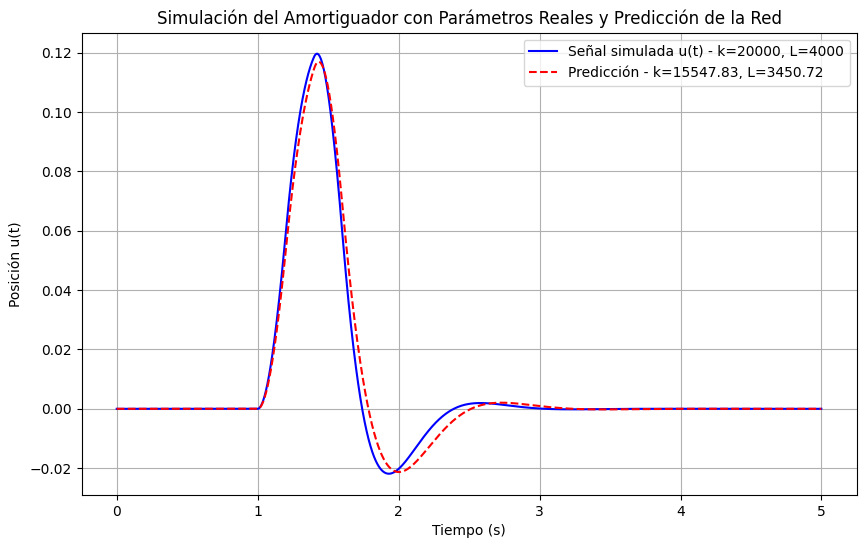

In [98]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# Funciones para c(t) y c'(t) por tramos (mismo código que proporcionaste)
def c_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5 * (t - 1)
    elif 1.2 <= t < 1.4:
        return 0.1
    elif 1.4 <= t < 1.6:
        return -0.5 * (t - 1.6)
    else:
        return 0

def c_prime_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5
    elif 1.2 <= t < 1.4:
        return 0
    elif 1.4 <= t < 1.6:
        return -0.5
    else:
        return 0

# Método para simular la señal u(t) basado en las constantes k y L
def simulate_amortiguador(k, L, m=107647/200, t_end=5, h=0.001, beta=0.5):
    t_steps = int(t_end / h)  # número de pasos
    t_array = np.arange(t_steps) * h  # array de tiempo
    u = np.zeros(t_steps)
    v = np.zeros(t_steps)
    u_n = 0.0  # Posición inicial
    v_n = 0.0  # Velocidad inicial
    u[0] = u_n
    v[0] = v_n

    for n in range(t_steps - 1):
        t_n = t_array[n]
        t_n1 = t_array[n] + h

        c_n = c_t(t_n)
        c_n1 = c_t(t_n1)
        c_pn = c_prime_t(t_n)
        c_pn1 = c_prime_t(t_n1)

        denom = (beta**2) * (h**2) * k + beta * L * h + m

        u[n + 1] = (
            - (beta**2) * L * c_pn * h**2
            + (beta**2) * L * c_pn1 * h**2
            - (beta**2) * c_n * h**2 * k
            + (beta**2) * c_n1 * h**2 * k
            + (beta**2) * h**2 * k * u[n]
            + beta * L * c_pn * h**2
            + beta * L * h * u[n]
            + beta * c_n * h**2 * k
            - beta * h**2 * k * u[n]
            + h * m * v[n]
            + m * u[n]
        ) / denom

        v[n + 1] = (
            (beta**2) * h**2 * k * v[n]
            - beta * L * c_pn * h
            + beta * L * c_pn1 * h
            + beta * L * h * v[n]
            - beta * c_n * h * k
            + beta * c_n1 * h * k
            - beta * h**2 * k * v[n]
            + L * c_pn * h
            - L * h * v[n]
            + c_n * h * k
            - h * k * u[n]
            + m * v[n]
        ) / denom

    return u  # Regresar la señal u(t)

# Función para generar datos de entrenamiento y prueba
def generate_data(num_samples=1000):
    X = []
    y = []
    for _ in range(num_samples):
        k = np.random.uniform(10000, 30000)  # Rango de k
        L = np.random.uniform(5000, 10000)   # Rango de L
        u = simulate_amortiguador(k, L)
        X.append(u)
        y.append([k, L])
    return np.array(X), np.array(y)

# Generar datos de entrenamiento
X, y = generate_data(num_samples=2000)

# Estandarización de las señales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, input_shape=(5000,), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Salida: k y L
])

# Compilación del modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Configurar early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenamiento del modelo
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluar el modelo con los datos de prueba
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

# Evaluar con una nueva señal para verificar la predicción de k y L
new_signal = simulate_amortiguador(20000, 6833.3333)  # Genera la señal con k=20000, L=6833.3333
new_signal_scaled = scaler.transform([new_signal])  # Estandarizar la nueva señal

# Predecir los valores de k y L
predicted_constants = model.predict(new_signal_scaled)
print(f"Predicción para k y L: {predicted_constants}")

# Graficar la señal generada con k_real y L_real
t_array = np.arange(5000) * 0.001
plt.figure(figsize=(10, 6))
plt.plot(t_array, new_signal, label="Señal simulada u(t) - k=20000, L=4000", color="blue")

# Graficar la señal con los k y L predichos
predicted_signal = simulate_amortiguador(predicted_constants[0][0], predicted_constants[0][1])
plt.plot(t_array, predicted_signal, label=f"Predicción - k={predicted_constants[0][0]:.2f}, L={predicted_constants[0][1]:.2f}", color="red", linestyle="--")

# Personalizar y mostrar gráfico
plt.title("Simulación del Amortiguador con Parámetros Reales y Predicción de la Red")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.grid(True)
plt.legend()
plt.show()



In [103]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# Funciones para c(t) y c'(t) por tramos (mismo código que proporcionaste)
def c_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5 * (t - 1)
    elif 1.2 <= t < 1.4:
        return 0.1
    elif 1.4 <= t < 1.6:
        return -0.5 * (t - 1.6)
    else:
        return 0

def c_prime_t(t):
    if t < 1:
        return 0
    elif 1 <= t < 1.2:
        return 0.5
    elif 1.2 <= t < 1.4:
        return 0
    elif 1.4 <= t < 1.6:
        return -0.5
    else:
        return 0

# Método para simular la señal u(t) basado en las constantes k y L
def simulate_amortiguador_constante(k, L, m=107647/200, t_end=5, h=0.001, beta=0.5, c=0.1, c_prime=0):
    t_steps = int(t_end / h)
    t_array = np.arange(t_steps) * h
    u = np.zeros(t_steps)
    v = np.zeros(t_steps)
    u_n = 0.0
    v_n = 0.0
    u[0] = u_n
    v[0] = v_n

    for n in range(t_steps - 1):
        u[n + 1] = ((beta**2) * (h**2) * k * u[n] + beta * L * c_prime * (h**2) + beta * L * h * u[n] + beta * c * (h**2) * k - beta * (h**2) * k * u[n] + h * m * v[n] + m * u[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)
        v[n + 1] = ((beta**2) * (h**2) * k * v[n] + beta * L * h * v[n] - beta * (h**2) * k * v[n] + L * c_prime * h - L * h * v[n] + c * h * k - h * k * u[n] + m * v[n]) / ((beta**2) * (h**2) * k + beta * L * h + m)

    return u

# Función para generar datos de entrenamiento y prueba
def generate_data(num_samples=1000):
    X = []
    y = []
    for _ in range(num_samples):
        k = np.random.uniform(10000, 30000)
        L = 0
        u = simulate_amortiguador_constante(k, L)
        X.append(u)
        y.append([k, L])
    return np.array(X), np.array(y)

# Generar datos de entrenamiento
X, y = generate_data(num_samples=10000)


Epoch 1/100


c:\Users\Cristian\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 43978448.0000 - val_loss: 691769.1875
Epoch 2/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3707843.2500 - val_loss: 93136.2812
Epoch 3/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3627912.0000 - val_loss: 115746.2578
Epoch 4/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3250494.2500 - val_loss: 477635.5938
Epoch 5/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3294957.0000 - val_loss: 346058.4688
Epoch 6/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3306751.2500 - val_loss: 359837.0312
Epoch 7/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3217060.5000 - val_loss: 297271.1875
Epoch 8/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3282018.5000 - val_loss: 309704.0000
Epoch 9/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3236255.2500 - val_loss: 1660449.8750
Epoch 10/100
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3260930.7500 - val_loss: 135836.9219
Epoch 11/1

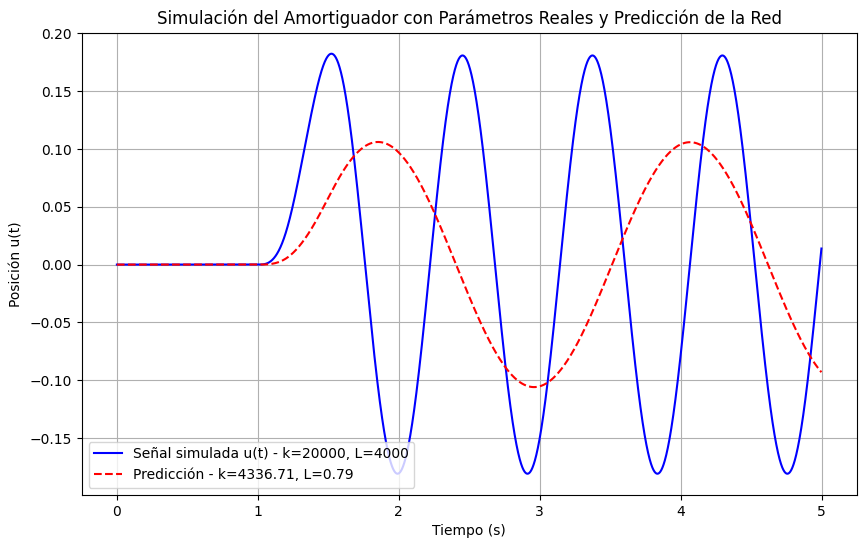

In [104]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping



# Estandarización de las señales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# Definir la red neuronal
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, input_shape=(5000,), activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2)  # Salida: k y L
])

# Compilación del modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Configurar early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenamiento del modelo
model.fit(X_train, y_train, epochs=100, batch_size=6, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Evaluar el modelo con los datos de prueba
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

# Evaluar con una nueva señal para verificar la predicción de k y L
new_signal = simulate_amortiguador(25000, 0)  # Genera la señal con k=20000, L=6833.3333
new_signal_scaled = scaler.transform([new_signal])  # Estandarizar la nueva señal

# Predecir los valores de k y L
predicted_constants = model.predict(new_signal_scaled)
print(f"Predicción para k y L: {predicted_constants}")

# Graficar la señal generada con k_real y L_real
t_array = np.arange(5000) * 0.001
plt.figure(figsize=(10, 6))
plt.plot(t_array, new_signal, label="Señal simulada u(t) - k=20000, L=4000", color="blue")

# Graficar la señal con los k y L predichos
predicted_signal = simulate_amortiguador(predicted_constants[0][0], predicted_constants[0][1])
plt.plot(t_array, predicted_signal, label=f"Predicción - k={predicted_constants[0][0]:.2f}, L={predicted_constants[0][1]:.2f}", color="red", linestyle="--")

# Personalizar y mostrar gráfico
plt.title("Simulación del Amortiguador con Parámetros Reales y Predicción de la Red")
plt.xlabel("Tiempo (s)")
plt.ylabel("Posición u(t)")
plt.grid(True)
plt.legend()
plt.show()

In [106]:
y

array([[13565.50224487,     0.        ],
       [13759.46579699,     0.        ],
       [23440.22374335,     0.        ],
       ...,
       [27977.71721088,     0.        ],
       [18643.13864883,     0.        ],
       [12881.44925563,     0.        ]])

Epoch 1/50


c:\Users\Cristian\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 97.0338 - val_loss: 32.1795
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 18.6552 - val_loss: 1.5053
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1192 - val_loss: 0.4090
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3013 - val_loss: 0.1749
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1531 - val_loss: 0.1267
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1033 - val_loss: 0.0923
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0843 - val_loss: 0.0753
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0695 - val_loss: 0.0612
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0573 - val_loss: 0.0525
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0451 - val_loss: 0.0475
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0418 - val_loss: 0.0405
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0375 - val_loss: 0.03

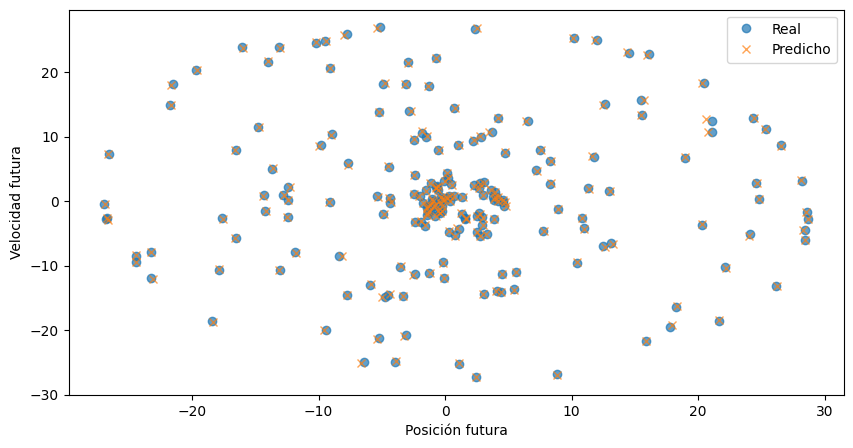

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Definir el sistema dinámico (ejemplo: sistema masa-resorte-amortiguador)
def sistema_dinamico(x, v, u, dt, m=1, k=1, c=0.1):
    """
    Sistema masa-resorte-amortiguador.
    x: posición actual
    v: velocidad actual
    u: fuerza aplicada
    dt: paso de tiempo
    m: masa
    k: constante del resorte
    c: constante de amortiguamiento
    """
    a = (u - k * x - c * v) / m
    v_next = v + a * dt
    x_next = x + v * dt
    return x_next, v_next

# Generar datos del sistema
def generar_datos(num_samples=1000, dt=0.1):
    x_data, v_data, u_data, y_data = [], [], [], []
    x, v = 0.0, 0.0  # Condiciones iniciales
    for _ in range(num_samples):
        u = np.random.uniform(-10, 10)  # Entrada aleatoria (fuerza aplicada)
        x_next, v_next = sistema_dinamico(x, v, u, dt)
        x_data.append(x)
        v_data.append(v)
        u_data.append(u)
        y_data.append([x_next, v_next])
        x, v = x_next, v_next  # Actualizar estado
    return np.array(x_data), np.array(v_data), np.array(u_data), np.array(y_data)

# 2. Crear el dataset
x_data, v_data, u_data, y_data = generar_datos()
X = np.stack([x_data, v_data, u_data], axis=1)  # Entradas: [posición, velocidad, fuerza]
y = y_data  # Salidas: [posición futura, velocidad futura]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Definir la red neuronal
model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(64, activation='relu'),
    Dense(2)  # Salida: [posición futura, velocidad futura]
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# 4. Validar el modelo
loss = model.evaluate(X_test, y_test)
print(f"Error cuadrático medio en el conjunto de prueba: {loss:.4f}")

# Predicciones
y_pred = model.predict(X_test)

# Graficar resultados
plt.figure(figsize=(10, 5))
plt.plot(y_test[:, 0], y_test[:, 1], 'o', label="Real", alpha=0.7)
plt.plot(y_pred[:, 0], y_pred[:, 1], 'x', label="Predicho", alpha=0.7)
plt.xlabel("Posición futura")
plt.ylabel("Velocidad futura")
plt.legend()
plt.show()


Epoch 1/30


c:\Users\Cristian\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 6.9331 - val_loss: 0.0538
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0397 - val_loss: 0.0160
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0124 - val_loss: 0.0025
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 5.3476e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.5719e-04 - val_loss: 2.0318e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.8000e-04 - val_loss: 9.7655e-05
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.3031e-04 - val_loss: 9.9604e-05
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.4052e-04 - val_loss: 8.1556e-05
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.2942e-05 - val_loss: 4.3670e-05
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.5415e-05 - val_loss: 5.9578e-05
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 5.3957e-05 - val_loss: 1.1383e-04
Epoch 12/30
50

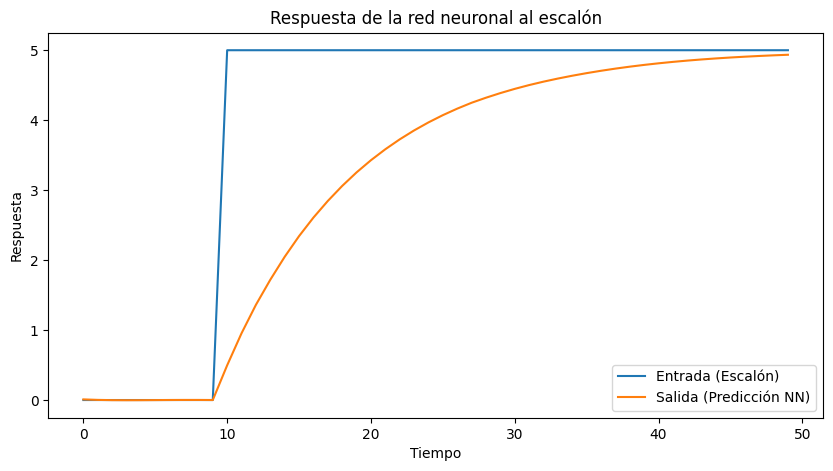

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.optimizers import Adam

# 1. Definir la planta (ejemplo: sistema de primer orden con retardo)
def planta(y_prev, u, dt, tau=1.0, k=1.0):
    """
    Sistema de primer orden: dy/dt = (-y + k*u) / tau
    """
    dy = (-y_prev + k * u) / tau
    return y_prev + dy * dt

# 2. Generar datos de la planta
def generar_datos_planta(num_samples=1000, seq_len=50, dt=0.1):
    """
    Genera datos para entrenar la red neuronal.
    - num_samples: número total de muestras.
    - seq_len: longitud de las secuencias temporales.
    """
    X, y = [], []
    for _ in range(num_samples):
        u = np.zeros(seq_len)  # Entrada escalón
        u[10:] = np.random.uniform(1, 10)  # Escalón desde el paso 10
        y_seq = []
        y_prev = 0.0  # Estado inicial
        for t in range(seq_len):
            y_next = planta(y_prev, u[t], dt)
            y_seq.append(y_next)
            y_prev = y_next
        X.append(u)
        y.append(y_seq)
    return np.array(X), np.array(y)

# Generar datos
seq_len = 50
X, y = generar_datos_planta(num_samples=2000, seq_len=seq_len)
X = X[..., np.newaxis]  # Añadir dimensión para la entrada a LSTM
y = y[..., np.newaxis]  # Salida también en formato de secuencia

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Definir la red neuronal LSTM
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, 1), return_sequences=True),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))  # Predice la salida en cada paso temporal
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# 4. Validar el modelo con un escalón
u_test = np.zeros(seq_len)
u_test[10:] = 5  # Escalón de entrada
u_test = u_test[np.newaxis, ..., np.newaxis]  # Ajustar forma para el modelo

y_pred = model.predict(u_test).flatten()

# Graficar entrada y salida
plt.figure(figsize=(10, 5))
plt.plot(range(seq_len), u_test.flatten(), label="Entrada (Escalón)")
plt.plot(range(seq_len), y_pred, label="Salida (Predicción NN)")
plt.xlabel("Tiempo")
plt.ylabel("Respuesta")
plt.legend()
plt.title("Respuesta de la red neuronal al escalón")
plt.show()


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 69.0318 - val_loss: 43.7398
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 38.0238 - val_loss: 32.7911
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 32.1207 - val_loss: 31.3434
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 31.7302 - val_loss: 31.8595
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 32.0535 - val_loss: 31.3853
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 31.4728 - val_loss: 30.8282
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 32.0941 - val_loss: 31.1593
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 31.1056 - val_loss: 32.1533
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 31.4810 - val_loss: 31.4583
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 31.4425 - val_loss: 32.0411
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 31.8225 - val_loss: 31.7935
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s

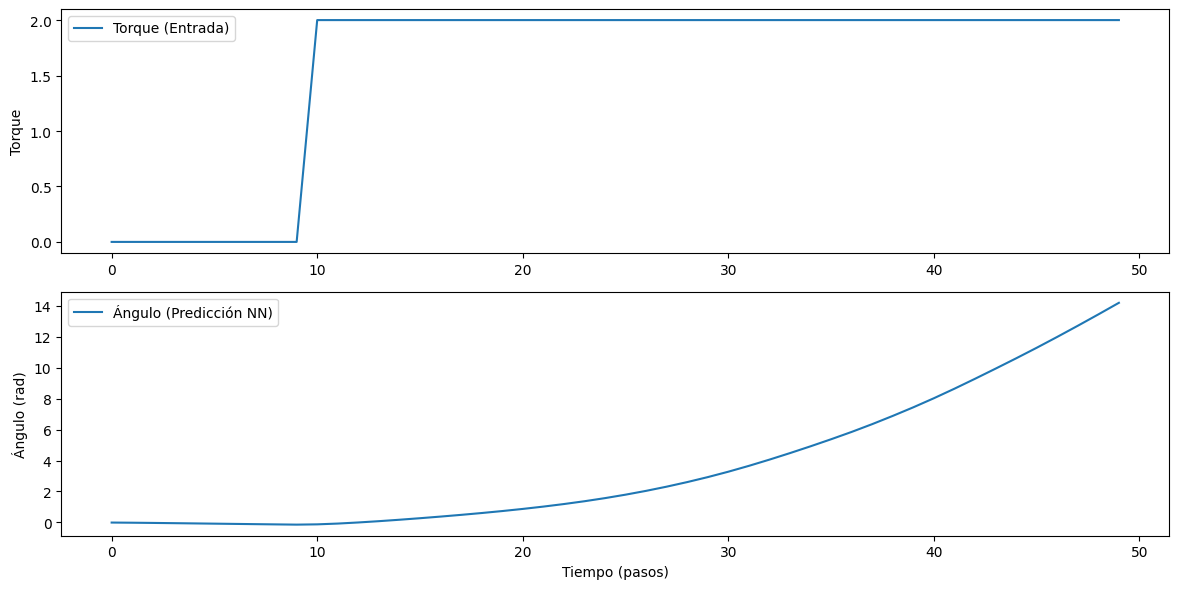

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, TimeDistributed
from tensorflow.keras.optimizers import Adam

# 1. Definir la planta: péndulo con rozamiento
def pendulo_dinamica(theta, omega, tau, dt, g=9.81, L=1.0, b=0.1, m=1.0):
    """
    Simula un paso del péndulo con rozamiento.
    theta: ángulo actual.
    omega: velocidad angular actual.
    tau: torque aplicado.
    dt: paso de tiempo.
    g: gravedad.
    L: longitud del péndulo.
    b: coeficiente de fricción.
    m: masa del péndulo.
    """
    alpha = (tau - b * omega - (m * g * L * np.sin(theta))) / (m * L**2)  # Aceleración angular
    omega_next = omega + alpha * dt  # Actualizar velocidad angular
    theta_next = theta + omega * dt  # Actualizar ángulo
    return theta_next, omega_next

# 2. Generar datos de la planta
def generar_datos_pendulo(num_samples=1000, seq_len=50, dt=0.1):
    """
    Genera datos del péndulo con rozamiento.
    - num_samples: número total de muestras.
    - seq_len: longitud de las secuencias temporales.
    """
    X, y = [], []
    for _ in range(num_samples):
        tau = np.zeros(seq_len)  # Entrada: torque aplicado
        tau[10:] = np.random.uniform(-5, 5)  # Aplicar un torque aleatorio después de 10 pasos
        theta_seq, omega_seq = [], []
        theta, omega = np.random.uniform(-np.pi, np.pi), 0.0  # Estado inicial aleatorio
        for t in range(seq_len):
            theta_next, omega_next = pendulo_dinamica(theta, omega, tau[t], dt)
            theta_seq.append(theta_next)
            omega_seq.append(omega_next)
            theta, omega = theta_next, omega_next
        X.append(tau)
        y.append(np.stack([theta_seq, omega_seq], axis=1))  # Salida: [theta, omega]
    return np.array(X), np.array(y)

# Generar datos
seq_len = 50
X, y = generar_datos_pendulo(num_samples=2000, seq_len=seq_len)
X = X[..., np.newaxis]  # Añadir dimensión para la entrada
y = y  # Salida ya está en formato [seq_len, 2]

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Definir la red neuronal LSTM
model = Sequential([
    LSTM(128, activation='relu', input_shape=(seq_len, 1), return_sequences=True),
    LSTM(128, activation='relu', return_sequences=True),
    TimeDistributed(Dense(2))  # Predice [theta, omega] para cada paso temporal
])

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

# 4. Validar con un torque escalón
tau_test = np.zeros(seq_len)
tau_test[10:] = 2.0  # Escalón de torque
tau_test = tau_test[np.newaxis, ..., np.newaxis]  # Ajustar forma para el modelo

y_pred = model.predict(tau_test).squeeze()  # Predicción
theta_pred, omega_pred = y_pred[:, 0], y_pred[:, 1]

# Graficar resultados
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(range(seq_len), tau_test.squeeze(), label="Torque (Entrada)")
plt.ylabel("Torque")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(range(seq_len), theta_pred, label="Ángulo (Predicción NN)")
plt.ylabel("Ángulo (rad)")
plt.xlabel("Tiempo (pasos)")
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Simular datos de las plantas
def simular_tanque(flujo, nivel_inicial=0, dt=0.1, k=1.0, tau=5.0):
    niveles = []
    nivel = nivel_inicial
    for q in flujo:
        dnivel = (-nivel + k * q) / tau
        nivel += dnivel * dt
        niveles.append(nivel)
    return np.array(niveles)

def simular_pendulo(torque, theta_inicial=0, omega_inicial=0, dt=0.1, g=9.81, L=1.0, b=0.1, m=1.0):
    thetas = []
    omega = omega_inicial
    theta = theta_inicial
    for tau in torque:
        alpha = (tau - b * omega - (m * g * L * np.sin(theta))) / (m * L**2)
        omega += alpha * dt
        theta += omega * dt
        thetas.append(theta)
    return np.array(thetas)

# Simular datos
def generar_datos(num_samples=1000, seq_len=50):
    X, y = [], []
    for _ in range(num_samples):
        tipo = np.random.choice([0, 1])  # 0: tanque, 1: péndulo
        entrada = np.random.uniform(0, 10, seq_len)
        if tipo == 0:  # Tanque
            salida = simular_tanque(entrada)
        elif tipo == 1:  # Péndulo
            salida = simular_pendulo(entrada)
        X.append(np.stack([entrada, salida], axis=1))
        y.append(tipo)
    return np.array(X), np.array(y)

# Generar datos
seq_len = 50
X, y = generar_datos(num_samples=2000, seq_len=seq_len)

# Codificar etiquetas
y = to_categorical(y, num_classes=2)

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Diseñar la red neuronal
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_len, 2), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(2, activation='softmax')  # Salida con 2 clases: tanque, péndulo
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Entrenar el modelo
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# 4. Evaluar el modelo
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Precisión en prueba: {test_accuracy:.2f}")

# 5. Validar con datos nuevos
nuevo_entrada = np.random.uniform(0, 10, seq_len)
nuevo_salida = simular_tanque(nuevo_entrada)  # Prueba con un tanque
nuevo_dato = np.stack([nuevo_entrada, nuevo_salida], axis=1)[np.newaxis, ...]

prediccion = model.predict(nuevo_dato)
print(f"Predicción: {'Tanque' if np.argmax(prediccion) == 0 else 'Péndulo'}")


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7646 - loss: 0.4768 - val_accuracy: 0.9950 - val_loss: 0.0347
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9498 - loss: 0.1713 - val_accuracy: 0.9725 - val_loss: 0.1139
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9648 - loss: 0.1405 - val_accuracy: 0.9975 - val_loss: 0.0494
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9339 - loss: 0.3618 - val_accuracy: 0.9950 - val_loss: 0.0391
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9758 - loss: 0.1078 - val_accuracy: 0.9825 - val_loss: 0.1436
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9794 - loss: 0.1297 - val_accuracy: 0.9875 - val_loss: 0.0549
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9904 - loss: 0.0506 - val_accuracy: 0.9975 - val_loss: 0.0111
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9816 - loss: 0.0804 - val_accuracy: 0.9900 - val_loss

In [6]:
import numpy as np
from scipy.optimize import minimize

# Supongamos que ya tienes un modelo neuronal llamado "model" que predice la planta
# Ejemplo de función: y_pred = model.predict(X)

# 1. Definir la función de costo para MPC
def costo_mpc(u_seq, y_actual, ref, horizon, dt):
    """
    Calcula el costo del control para el horizonte dado.
    - u_seq: Secuencia de entradas propuestas.
    - y_actual: Estado actual de la planta.
    - ref: Referencia deseada.
    - horizon: Horizonte de predicción.
    """
    costo = 0
    y_pred = y_actual
    for k in range(horizon):
        # Crear entrada y salida simulada
        u = u_seq[k]
        entrada_modelo = np.array([[u, y_pred]])  # Entradas para el modelo neuronal
        y_pred = model.predict(entrada_modelo).squeeze()  # Predicción de la planta
        
        # Costo: Error cuadrático más penalización por el control
        costo += (ref - y_pred)**2 + 0.1 * u**2  # Penalización por control agresivo
    return costo

# 2. Simular la planta controlada
def simular_control(model, ref, pasos, horizon, dt):
    """
    Simula el sistema controlado usando MPC.
    - model: Modelo neuronal de la planta.
    - ref: Referencia deseada.
    - pasos: Número de pasos de simulación.
    - horizon: Horizonte de predicción.
    - dt: Paso de tiempo.
    """
    y_actual = 0.0  # Estado inicial de la planta
    historial_y = [y_actual]
    historial_u = []

    for t in range(pasos):
        # Optimizar la secuencia de control
        u_inicial = np.zeros(horizon)  # Entrada inicial (horizonte de predicción)
        resultado = minimize(
            costo_mpc,
            u_inicial,
            args=(y_actual, ref, horizon, dt),
            bounds=[(-10, 10)] * horizon,  # Limites de control
            method="SLSQP"
        )
        u_opt = resultado.x[0]  # Tomar la primera acción óptima

        # Aplicar el control y simular la planta
        entrada_modelo = np.array([[u_opt, y_actual]])  # Entradas para el modelo neuronal
        y_actual = model.predict(entrada_modelo).squeeze()  # Actualizar el estado de la planta
        
        # Guardar resultados
        historial_y.append(y_actual)
        historial_u.append(u_opt)

    return np.array(historial_y), np.array(historial_u)

# 3. Configurar y correr la simulación
ref = 5.0  # Referencia deseada
pasos = 50
horizon = 10
dt = 0.1

historial_y, historial_u = simular_control(model, ref, pasos, horizon, dt)

# 4. Graficar resultados
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(historial_y, label="Salida (y)")
plt.axhline(ref, color="r", linestyle="--", label="Referencia (r)")
plt.ylabel("Salida")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(historial_u, label="Control (u)")
plt.ylabel("Control")
plt.xlabel("Tiempo")
plt.legend()

plt.tight_layout()
plt.show()


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None